In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

project_root

WindowsPath('c:/Users/Dell - i5 11th Gen/Desktop/atm-protein-conservation-explorer')

In [2]:
position_scores_file = project_root / "data" / "processed" / "position_scores.csv"
variant_scores_file = project_root / "data" / "processed" / "variant_scores.csv"

position_scores = pd.read_csv(position_scores_file)
variant_scores = pd.read_csv(variant_scores_file)

print(f"Position rows: {len(position_scores)}")
print(f"Variant rows: {len(variant_scores)}")

variant_scores.head()

Position rows: 1793
Variant rows: 4526


,Unnamed: 0,gene,clinvar_variation_id,vcv_accession,rs_id,clinvar_variation,transcript,hgvs_c,hgvs_p,protein_change,...,usable_species_count,matching_species_count,gap_species_count,ambiguous_species_count,conservation_score,conservation_percent,reference_matches_human,alternate_species_count,alternate_species_fraction,alternate_seen_in_species
0,0,ATM,4170131,VCV004170131,rs4279232,NM_000051.4(ATM):c.4A>C (p.Ser2Arg),NM_000051.4,c.4A>C,p.Ser2Arg,S2R,...,814,761,12,0,0.934889,93.488943,True,0,0.000000,False
1,1,ATM,640846,VCV000640846,rs639367,NM_000051.4(ATM):c.4A>G (p.Ser2Gly),NM_000051.4,c.4A>G,p.Ser2Gly,S2G,...,814,761,12,0,0.934889,93.488943,True,0,0.000000,False
2,2,ATM,181943,VCV000181943,rs180377,NM_000051.4(ATM):c.5G>C (p.Ser2Thr),NM_000051.4,c.5G>C,p.Ser2Thr,S2T,...,814,761,12,0,0.934889,93.488943,True,6,0.007371,True
3,3,ATM,922075,VCV000922075,rs911284,NM_000051.4(ATM):c.6T>A (p.Ser2Arg),NM_000051.4,c.6T>A,p.Ser2Arg,S2R,...,814,761,12,0,0.934889,93.488943,True,0,0.000000,False
4,4,ATM,1337452,VCV001337452,rs1328461,NM_000051.4(ATM):c.6T>G (p.Ser2Arg),NM_000051.4,c.6T>G,p.Ser2Arg,S2R,...,814,761,12,0,0.934889,93.488943,True,0,0.000000,False


In [3]:
required_columns = {
    "protein_position", "human_residue", "conservation_score",
    "conservation_percent", "usable_species_count",
}
missing_columns = required_columns - set(position_scores.columns)

if missing_columns:
    raise ValueError(f"Missing position columns: {sorted(missing_columns)}")

if position_scores["protein_position"].duplicated().any():
    raise ValueError("Duplicate protein positions in position_scores.")

if not position_scores["conservation_score"].between(0, 1).all():
    raise ValueError("Conservation scores outside 0-1.")

print("Position scores OK.")

Position scores OK.


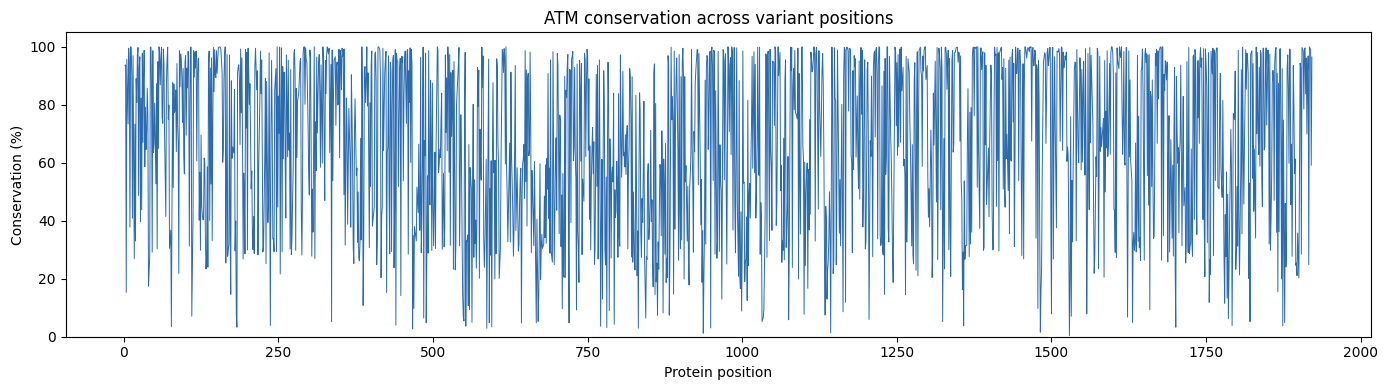

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(position_scores["protein_position"], position_scores["conservation_percent"], linewidth=0.7, color="#2b6cb0")
ax.set_xlabel("Protein position")
ax.set_ylabel("Conservation (%)")
ax.set_title("ATM conservation across variant positions")
ax.set_ylim(0, 105)
fig.tight_layout()
fig.savefig(figures_dir / "atm_wide_conservation.png", dpi=300)
plt.show()

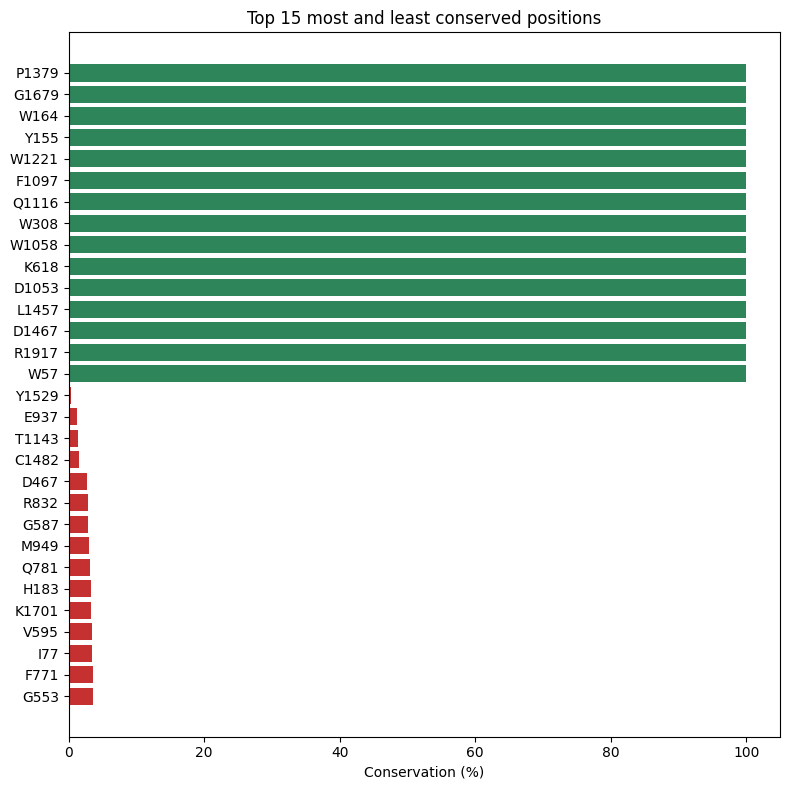

In [5]:
n_top = 15
ranked_positions = position_scores.sort_values("conservation_percent")

least_conserved = ranked_positions.head(n_top)
most_conserved = ranked_positions.tail(n_top).sort_values("conservation_percent", ascending=False)
ranked_subset = pd.concat([most_conserved, least_conserved])

labels = [f"{r.human_residue}{int(r.protein_position)}" for r in ranked_subset.itertuples()]
colors = ["#2f855a"] * n_top + ["#c53030"] * n_top

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(labels, ranked_subset["conservation_percent"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Conservation (%)")
ax.set_title(f"Top {n_top} most and least conserved positions")
fig.tight_layout()
fig.savefig(figures_dir / "ranked_conservation.png", dpi=300)
plt.show()

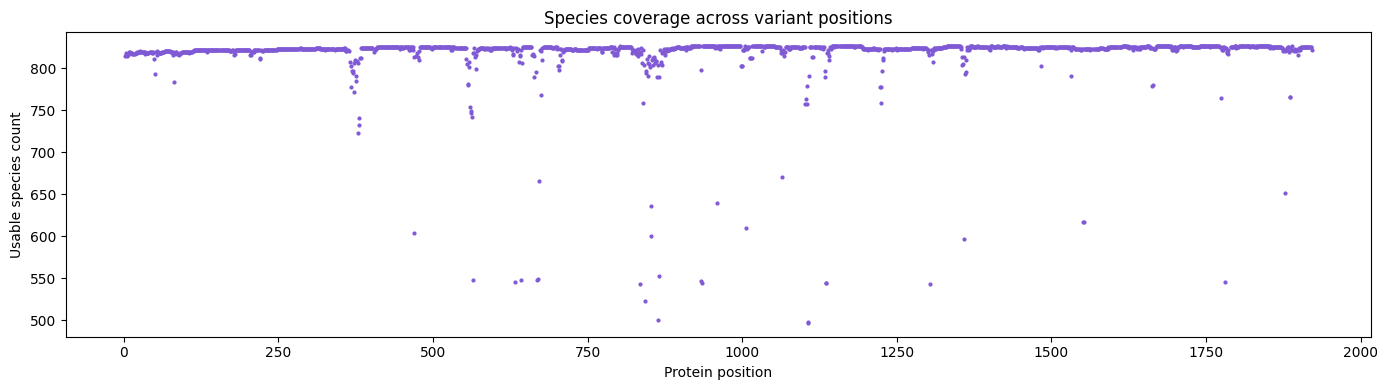

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(position_scores["protein_position"], position_scores["usable_species_count"], s=4, color="#805ad5")
ax.set_xlabel("Protein position")
ax.set_ylabel("Usable species count")
ax.set_title("Species coverage across variant positions")
fig.tight_layout()
fig.savefig(figures_dir / "species_coverage.png", dpi=300)
plt.show()

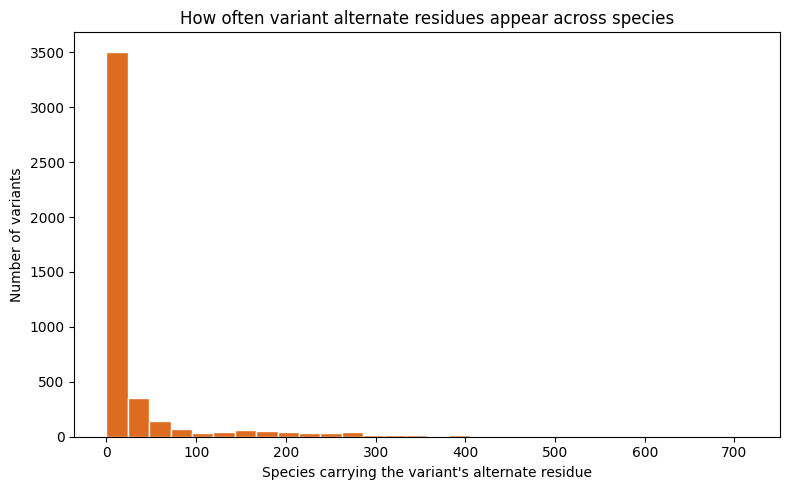

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(variant_scores["alternate_species_count"], bins=30, color="#dd6b20", edgecolor="white")
ax.set_xlabel("Species carrying the variant's alternate residue")
ax.set_ylabel("Number of variants")
ax.set_title("How often variant alternate residues appear across species")
fig.tight_layout()
fig.savefig(figures_dir / "alternate_residue_distribution.png", dpi=300)
plt.show()

In [8]:
drop_columns = [col for col in ["Unnamed: 0", "reference_matches_human"] if col in variant_scores.columns]

final_dataset = (
    variant_scores.drop(columns=drop_columns)
    .sort_values(["protein_position", "protein_change"])
    .reset_index(drop=True)
)

if final_dataset["conservation_percent"].isna().any():
    raise ValueError("Some variants are missing conservation scores.")

print(f"Final dataset rows: {len(final_dataset)}")
print(f"Final dataset columns: {len(final_dataset.columns)}")
final_dataset.head()

Final dataset rows: 4526
Final dataset columns: 41


,gene,clinvar_variation_id,vcv_accession,rs_id,clinvar_variation,transcript,hgvs_c,hgvs_p,protein_change,protein_position,...,comparison_species_count,usable_species_count,matching_species_count,gap_species_count,ambiguous_species_count,conservation_score,conservation_percent,alternate_species_count,alternate_species_fraction,alternate_seen_in_species
0,ATM,640846,VCV000640846,rs639367,NM_000051.4(ATM):c.4A>G (p.Ser2Gly),NM_000051.4,c.4A>G,p.Ser2Gly,S2G,2,...,826,814,761,12,0,0.934889,93.488943,0,0.000000,False
1,ATM,4170131,VCV004170131,rs4279232,NM_000051.4(ATM):c.4A>C (p.Ser2Arg),NM_000051.4,c.4A>C,p.Ser2Arg,S2R,2,...,826,814,761,12,0,0.934889,93.488943,0,0.000000,False
2,ATM,922075,VCV000922075,rs911284,NM_000051.4(ATM):c.6T>A (p.Ser2Arg),NM_000051.4,c.6T>A,p.Ser2Arg,S2R,2,...,826,814,761,12,0,0.934889,93.488943,0,0.000000,False
3,ATM,1337452,VCV001337452,rs1328461,NM_000051.4(ATM):c.6T>G (p.Ser2Arg),NM_000051.4,c.6T>G,p.Ser2Arg,S2R,2,...,826,814,761,12,0,0.934889,93.488943,0,0.000000,False
4,ATM,181943,VCV000181943,rs180377,NM_000051.4(ATM):c.5G>C (p.Ser2Thr),NM_000051.4,c.5G>C,p.Ser2Thr,S2T,2,...,826,814,761,12,0,0.934889,93.488943,6,0.007371,True


In [9]:
final_output_file = project_root / "data" / "processed" / "atm_variant_explorer_final.csv"
final_dataset.to_csv(final_output_file, index=False)

print(f"Saved to: {final_output_file}")

Saved to: c:\Users\Dell - i5 11th Gen\Desktop\atm-protein-conservation-explorer\data\processed\atm_variant_explorer_final.csv


In [10]:
sorted(p.name for p in figures_dir.glob("*.png"))

['alternate_residue_distribution.png',
 'atm_wide_conservation.png',
 'ranked_conservation.png',
 'species_coverage.png']